# Appeals and Greivances EDA

Kenny Nguyen

## Importing Libraries

In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

## Importing Datasets

In [ ]:
mia <- read.csv("MIA Appeals and Grievances.csv")

In [ ]:
admin <- read.csv('Admin Complaints.csv')

## Looking at dataset attributes

In [ ]:
str(mia)

'data.frame':   178 obs. of  95 variables:
 $ company.name                                                                  : chr  "4 Ever Life Insurance Company" "Aetna Dental, Inc." "Aetna Health Inc. ( a Pennsylvania corporation )" "Aetna Health Insurance Company" ...
 $ naic..                                                                        : int  80985 95910 95109 NA 60054 95163 61301 96202 47058 NA ...
 $ year                                                                          : int  2021 2021 2021 2021 2021 2021 2021 2021 2021 2021 ...
 $ adverse.decisions.company.total                                               : int  1 693 115 NA 188 NA 285 21128 7057 NA ...
 $ adverse.decisions.by.carrier.percent                                          : num  0 0.009 0.001 NA 0.002 NA 0.004 0.26 0.087 NA ...
 $ adverse.decisions.inpatient.hospital.services.number                          : int  1 0 39 NA 69 NA 0 12 2 NA ...
 $ adverse.decisions.inpatient.hospital.services.perce

In [ ]:
colSums(is.na(mia))

                                                                  company.name 
                                                                             0 
                                                                        naic.. 
                                                                            44 
                                                                          year 
                                                                             0 
                                               adverse.decisions.company.total 
                                                                            25 
                                          adverse.decisions.by.carrier.percent 
                                                                            25 
                          adverse.decisions.inpatient.hospital.services.number 
                                                                            25 
                   adverse.decisions.inp

In [ ]:
summary(mia)

 company.name           naic..           year     
 Length:178         Min.   :21113   Min.   :2021  
 Class :character   1st Qu.:60321   1st Qu.:2021  
 Mode  :character   Median :68381   Median :2022  
                    Mean   :71058   Mean   :2022  
                    3rd Qu.:85766   3rd Qu.:2023  
                    Max.   :96940   Max.   :2024  
                    NA's   :44                    
 adverse.decisions.company.total adverse.decisions.by.carrier.percent
 Min.   :     1                  Min.   :0.00000                     
 1st Qu.:    27                  1st Qu.:0.00000                     
 Median :   286                  Median :0.00300                     
 Mean   :  5190                  Mean   :0.04993                     
 3rd Qu.:  1421                  3rd Qu.:0.01400                     
 Max.   :111426                  Max.   :1.00100                     
 NA's   :25                      NA's   :25                          
 adverse.decisions.inpatient.hos

In [ ]:
summary(admin)

      year      Type.of.Procedure  carrier.code           total       
 Min.   :2021   Length:70          Length:70          Min.   :  1.00  
 1st Qu.:2021   Class :character   Class :character   1st Qu.:  1.00  
 Median :2022   Mode  :character   Mode  :character   Median :  3.50  
 Mean   :2022                                         Mean   : 38.20  
 3rd Qu.:2023                                         3rd Qu.: 30.25  
 Max.   :2024                                         Max.   :395.00  
 upheld.by.MIA.number carrier.upheld.by.mia.percent reversed.by.mia.number
 Min.   :  0.00       Min.   :0.0000                Min.   :  0.00        
 1st Qu.:  0.00       1st Qu.:0.0000                1st Qu.:  0.00        
 Median :  2.00       Median :0.2975                Median :  1.00        
 Mean   : 11.69       Mean   :0.3407                Mean   : 10.31        
 3rd Qu.:  9.75       3rd Qu.:0.5000                3rd Qu.:  4.00        
 Max.   :131.00       Max.   :1.0000                M

## Fixing column names

In [ ]:
names(mia) <- tolower(names(mia))
names(mia) <- gsub(' ',"_",names(mia))
names(mia) <- gsub("\\.", "_",names(mia))

In [ ]:
names(admin) <- tolower(names(admin))
names(admin) <- gsub(' ',"_",names(admin))
names(admin) <- gsub("\\.", "_",names(admin))

In [ ]:
admin_totals_only <- admin |>
  filter(type_of_procedure == "Total")

In [ ]:
colnames(admin)

 [1] "year"                                                
 [2] "type_of_procedure"                                   
 [3] "carrier_code"                                        
 [4] "total"                                               
 [5] "upheld_by_mia_number"                                
 [6] "carrier_upheld_by_mia_percent"                       
 [7] "reversed_by_mia_number"                              
 [8] "carrier_reversed_by_mia_percent"                     
 [9] "modifed_by_mia_number"                               
[10] "carrier_modifed_by_mia_percent"                      
[11] "carrier_reversed_itself_during_investigation_number" 
[12] "carrier_reversed_itself_during_investigation_percent"

In [ ]:
colnames(mia)

 [1] "company_name"                                                                  
 [2] "naic__"                                                                        
 [3] "year"                                                                          
 [4] "adverse_decisions_company_total"                                               
 [5] "adverse_decisions_by_carrier_percent"                                          
 [6] "adverse_decisions_inpatient_hospital_services_number"                          
 [7] "adverse_decisions_inpatient_hospital_services_percent_total"                   
 [8] "adverse_decisions_emergency_room_services_number"                              
 [9] "adverse_decisions_emergency_room_services_percent_total"                       
[10] "adverse_decisions_mental_health_services_number"                               
[11] "adverse_decisions_mental_health_services_percent_total"                        
[12] "adverse_decisions_physician_services_number"    

## Creating a dataset that contains only total amounts

In [ ]:
totals_only <- mia |>
  filter(company_name == "Total")

In [ ]:
str(admin)

'data.frame':   70 obs. of  12 variables:
 $ year                                                : int  2021 2021 2021 2021 2021 2021 2021 2021 2021 2021 ...
 $ type_of_procedure                                   : chr  "Air Ambulance" "Cosmetic" "Dental Care Services" "Durable Medical Equipment" ...
 $ carrier_code                                        : chr  "B" "D" "J" "I" ...
 $ total                                               : int  2 3 32 7 2 6 1 2 45 1 ...
 $ upheld_by_mia_number                                : int  2 0 10 2 0 4 0 2 27 0 ...
 $ carrier_upheld_by_mia_percent                       : num  1 0 0.31 0.29 0 0.67 0 1 0.6 0 ...
 $ reversed_by_mia_number                              : int  0 2 4 3 0 1 1 0 11 0 ...
 $ carrier_reversed_by_mia_percent                     : num  0 0.67 0.13 0.43 0 0.17 1 0 0.24 0 ...
 $ modifed_by_mia_number                               : int  0 1 1 0 0 0 0 0 0 0 ...
 $ carrier_modifed_by_mia_percent                      : num  0 0.33 

# Adverse Decisions

## Creating a line graph to see the change in adverse decisions over the years

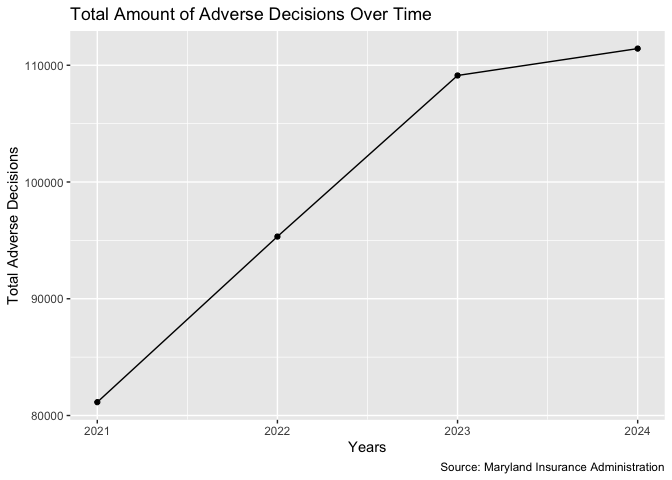

In [ ]:
adp1 <- totals_only |>
  select(year,adverse_decisions_company_total)|>
  ggplot(aes(x = year, y = adverse_decisions_company_total)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Total Amount of Adverse Decisions Over Time",
  caption = "Source: Maryland Insurance Administration",
  y = "Total Adverse Decisions",
x = "Years")

adp1

Throughout the years adverse decisions are increasing but the increase
seemed to slow down from 2023 to 2024 meaning claims are being less
rejected.

In [ ]:
adverse_growth <- totals_only |>
  select(year,adverse_decisions_company_total) |>
  arrange(year)|>
  mutate(
    pct_change = (adverse_decisions_company_total - lag(adverse_decisions_company_total)) / lag(adverse_decisions_company_total) * 100
  )

adverse_growth

  year adverse_decisions_company_total pct_change
1 2021                           81143         NA
2 2022                           95327  17.480251
3 2023                          109123  14.472290
4 2024                          111426   2.110463

## Creating dataset to collect the top ten companies with the most adverse decisions

In [ ]:
top_companies_ad <- mia |>
  filter(`company_name` != "Total") |>
  group_by(`company_name`) |>
  summarise(total = sum(`adverse_decisions_company_total`, na.rm = TRUE)) |>
  arrange(desc(total)) |>
  head(10)

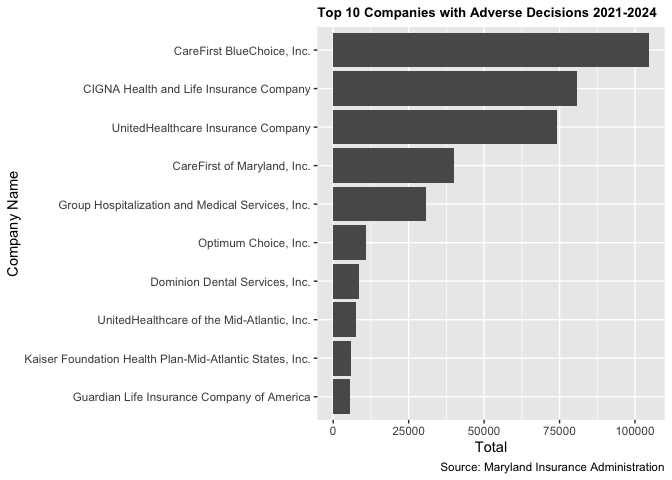

In [ ]:
ggplot(top_companies_ad, aes(x = reorder(`company_name`, total), y = total)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Top 10 Companies with Adverse Decisions 2021-2024",
    caption = 'Source: Maryland Insurance Administration',
    x = 'Company Name',
    y = 'Total'
  ) +
  theme(plot.title = element_text(size = 10, face = "bold"))

The top CareFirst BluChoice leads all companies with 104,612 adverse
decisions from 2021-2024

The top 3 insurers (CareFirst BluChoice, CIGNA, UnitedHealthcare)
account for the majority of all adverse decisions statewide

## Creating a dataset that has all the totals of the adverse services

In [ ]:
totals_adverse_services <- totals_only |>
  select(
    year,
    adverse_decisions_inpatient_hospital_services_number,
    adverse_decisions_emergency_room_services_number,
    adverse_decisions_mental_health_services_number,
   adverse_decisions_physician_services_number,
  adverse_decisions_laboratory__radiology_services_number,
    adverse_decisions_pharmacy_services_number,
    adverse_decisions_pt__ot__st_services__incl_inpat_rehab__number_,
    adverse_decisions_skilled_nurse_facility_sub_acute_nursing_home_number,
   adverse_decisions_durable_medical_equipment_services_number,
    adverse_decisions_dental_number,
    adverse_decisions_home_health_services_number,
    adverse_decisions_obesity__ivf__podiatry__hearing_and_vision_number_
  )

In [ ]:
totals_adverse_services_long <- totals_adverse_services |>
  pivot_longer(
    cols = -year,
    names_to = "service",
    values_to = "count"
  ) |>
  mutate(
    service = service |>
      str_remove("adverse_decisions") |>
      str_remove("_number_?$") |>
      str_replace_all("_", " ") |>
      str_to_title()
  )

## Calculating the percent change in adverse decision per service by years

In [ ]:
adverse_service_growth <- totals_adverse_services_long |>
  arrange(service, year) |>
  group_by(service) |>
  mutate(
    pct_change = (count - lag(count)) / lag(count) * 100
  ) |>
  ungroup() 


adverse_service_growth

# A tibble: 48 × 4
    year service                               count pct_change
   <int> <chr>                                 <int>      <dbl>
 1  2021 " Dental"                             15134     NA    
 2  2022 " Dental"                             15065     -0.456
 3  2023 " Dental"                             16732     11.1  
 4  2024 " Dental"                             16256     -2.84 
 5  2021 " Durable Medical Equipment Services"  1364     NA    
 6  2022 " Durable Medical Equipment Services"  1161    -14.9  
 7  2023 " Durable Medical Equipment Services"  1668     43.7  
 8  2024 " Durable Medical Equipment Services"  1554     -6.83 
 9  2021 " Emergency Room Services"               10     NA    
10  2022 " Emergency Room Services"              112   1020    
# ℹ 38 more rows

## Creating a heat map that shows the percent change in adverse decisions

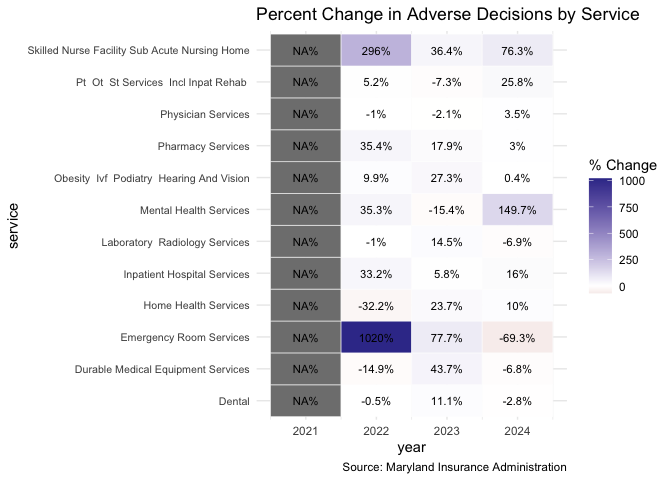

In [ ]:
ggplot(adverse_service_growth, aes(x = year, y = service, fill = pct_change)) +
  geom_tile(color = "white") +
  geom_text(aes(label = paste0(round(pct_change, 1), "%")), size = 3) +
  scale_fill_gradient2(
    name = "% Change"
  ) +
  labs(
    title = "Percent Change in Adverse Decisions by Service",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 8)
  )

Emergency Room Services saw a 1,020% spike in 2022 going from 10 to 112

Mental Health Services surged 149.7% in 2024

## Creating facet plots of the change in adverse decisions by service

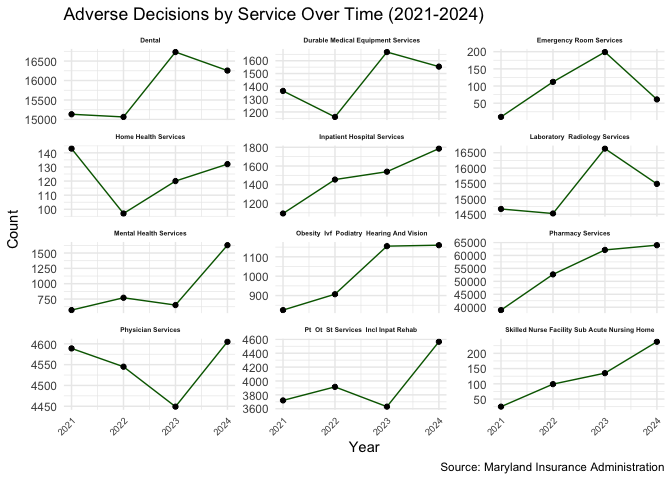

In [ ]:
ggplot(totals_adverse_services_long, aes(x = year, y = count)) +
  geom_line( color = "darkgreen") +
  geom_point() +
  facet_wrap(~ service, scales = "free_y", ncol = 3) +
  labs(
    title = "Adverse Decisions by Service Over Time (2021-2024)",
    x = "Year",
    y = "Count",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal() +
  theme(
    strip.text = element_text(size = 5, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  )

Pharmacy Services had the highest absolute volume and a consistent
upward trend, making it the largest driver of adverse decisions by
service, possibly due to burnt out workers and high quotas

Laboratory/Radiology & Emergency Services is the only category showing a
decline in 2024, contrasting with the broader upward trend across
services

# Grievances

## Creating a line graph to see the change in grievances over the years

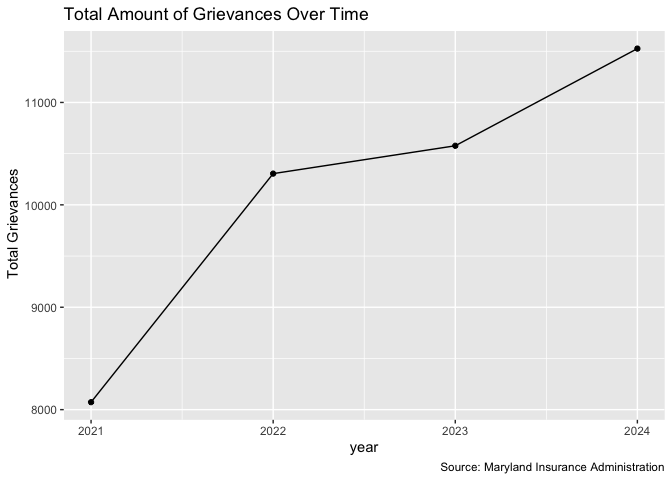

In [ ]:
grp1 <- totals_only |>
  select(year,grievances_filed_company_total)|>
  ggplot(aes(x = year, y = grievances_filed_company_total)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Total Amount of Grievances Over Time",
    caption = "Source: Maryland Insurance Administration",
    y = " Total Grievances"
  )
grp1

Total grievances grew 43% from 8,073 in 2021 to 11,526 in 2024,
indicating consumers are increasingly challenging insurance decisions.

## Calculating percent change in grievances by years

In [ ]:
grievance_growth <- totals_only |>
  select(year,grievances_filed_company_total) |>
  arrange(year) |>
  mutate(
    pct_change = (grievances_filed_company_total - lag(grievances_filed_company_total)) / lag(grievances_filed_company_total) * 100
  )

grievance_growth

  year grievances_filed_company_total pct_change
1 2021                           8073         NA
2 2022                          10305  27.647715
3 2023                          10577   2.639495
4 2024                          11526   8.972298

## Creating dataset to collect the top ten companies with the most grievances

In [ ]:
top_companies_gr <- mia |>
  filter(`company_name` != "Total") |>
  group_by(`company_name`) |>
  summarise(total = sum(`grievances_filed_company_total`, na.rm = TRUE)) |>
  arrange(desc(total)) |>
  head(10)

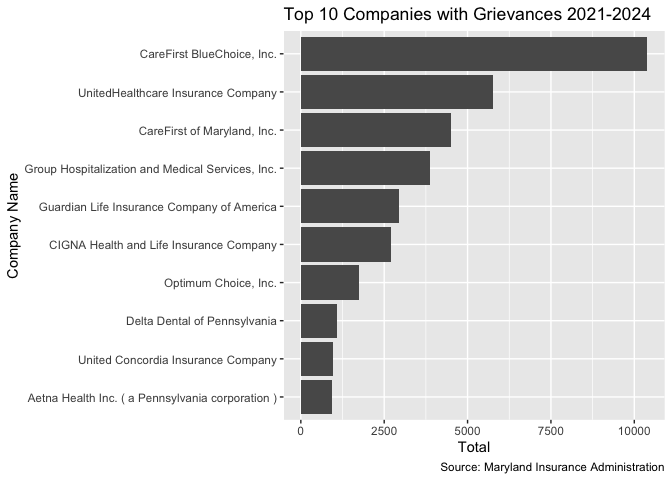

In [ ]:
  ggplot(top_companies_gr,aes(x = reorder(`company_name`, total), y = total)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Top 10 Companies with Grievances 2021-2024",
       x = 'Company Name',
       y= 'Total',
       caption = "Source: Maryland Insurance Administration"
       ) 

CareFirst BlueChoice ranks 1st in both adverse and grievances

Guardian Life ranks 5th for grievances yet 10th for adverse

## Creating a dataset that has the totals for grievances services

In [ ]:
totals_grievances_services <- totals_only |>
  select(
    year,
    grievance_inpatient_hospital_services_number,
    grievance_emergency_room_services_number,
    grievance_mental_health_services_number,
    grievance_physician_services_number,
    grievance_laboratory__radiology_services_number,
    grievance_pharmacy_services_number,
    grievance_pt__ot__st_services__incl_inpat_rehab__number_,
    grievance_skilled_nurse_facility_sub_acute_nursing_home_number,
    grievance_durable_medical_equipment_services_number,
    grievance_dental_number,
    grievance_home_health_services_number,
    grievance_obesity__ivf__podiatry__hearing_and_vision_number_
  )

In [ ]:
totals_grievances_services_long <- totals_grievances_services |>
  pivot_longer(
    cols = -year,
    names_to = "service",
    values_to = "count"
  ) |>
  mutate(
    service = service |>
      str_remove("grievance") |>
      str_remove("_number_?$") |>
      str_replace_all("_", " ") |>
      str_to_title()
  )

## Calculating the percent change in grievances per service by years

In [ ]:
grievance_service_growth <- totals_grievances_services_long |>
  arrange(service, year) |>
  group_by(service) |>
  mutate(
    pct_change = (count - lag(count)) / lag(count) * 100
  ) |>
  ungroup() |>
    mutate(
    service = service |>
      str_remove("grievance") |>
      str_remove("_number_?$") |>
      str_replace_all("_", " ") |>
      str_to_title() 
    )

grievance_service_growth

# A tibble: 48 × 4
    year service                               count pct_change
   <int> <chr>                                 <int>      <dbl>
 1  2021 " Dental"                              2375      NA   
 2  2022 " Dental"                              3169      33.4 
 3  2023 " Dental"                              2160     -31.8 
 4  2024 " Dental"                              1937     -10.3 
 5  2021 " Durable Medical Equipment Services"   123      NA   
 6  2022 " Durable Medical Equipment Services"   216      75.6 
 7  2023 " Durable Medical Equipment Services"   196      -9.26
 8  2024 " Durable Medical Equipment Services"   376      91.8 
 9  2021 " Emergency Room Services"               20      NA   
10  2022 " Emergency Room Services"               30      50   
# ℹ 38 more rows

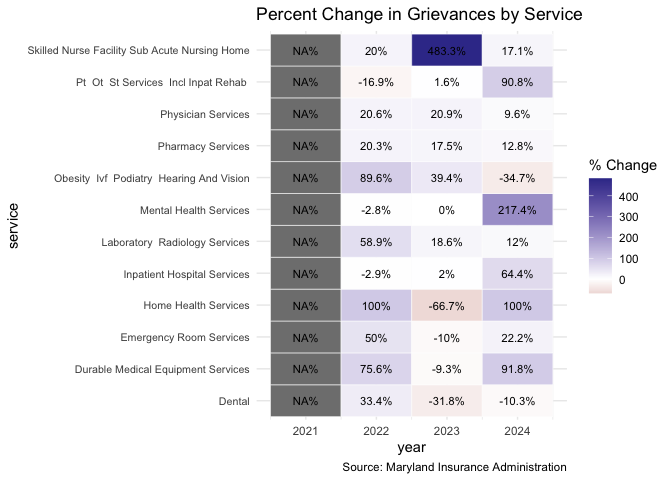

In [ ]:
ggplot(grievance_service_growth, aes(x = year, y = service, fill = pct_change)) +
  geom_tile(color = "white") +
  geom_text(aes(label = paste0(round(pct_change, 1), "%")), size = 3) +
  scale_fill_gradient2(
    name = "% Change"
  ) +
  labs(
    title = "Percent Change in Grievances by Service",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 8)
  )

Mental Health Services grievances surged 217.4% in 2024 — the largest
jump of any service category and a key area of concern. S

killed Nursing Facility grievances jumped 483.3% in 2023, then grew
another 17.1% in 2024, indicating a persistent and growing problem.

## Creating facet plots of the change in grievances by service

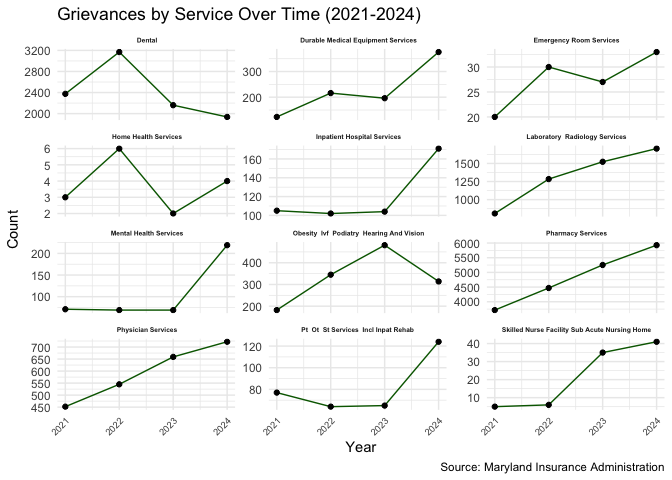

In [ ]:
ggplot(totals_grievances_services_long, aes(x = year, y = count)) +
  geom_line( color = "darkgreen") +
  geom_point() +
  facet_wrap(~ service, scales = "free_y", ncol = 3) +
  labs(
    title = "Grievances by Service Over Time (2021-2024)",
    x = "Year",
    y = "Count",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal() +
  theme(
    strip.text = element_text(size = 5, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  )

Pharmacy Services grievances are consistently high and rising

Mental Health Services shows a dramatic acceleration in 2024 after years
of relative stability — the most significant shift in this dataset.

## Creating bar chart with the totals amount of grievances outcomes from 2021 - 2024

In [ ]:
outcome <- totals_only |>
select(grievances_upheld_number,grievances_overturned_number,grievances_modified_number)|>
  pivot_longer(everything(), names_to = "outcome", values_to = "count") |>
mutate(outcome = outcome |>
      str_remove("grievances_") |>
      str_remove("_number") |>
      str_replace_all("_", " ") |>
      str_to_title()
)

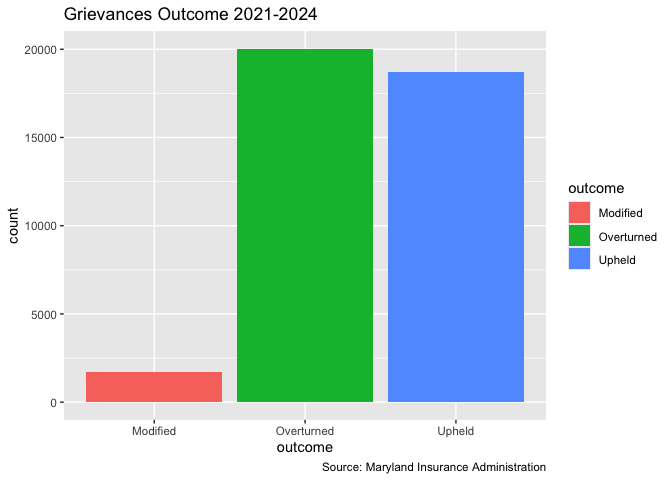

In [ ]:
ggplot(outcome,aes(x = outcome, y = count, fill = outcome)) +
  geom_bar(stat = "identity") +
labs(
  title = "Grievances Outcome 2021-2024",
  caption = "Source: Maryland Insurance Administration"
)

## Creating a line graph showing the trends of grievances outcome

In [ ]:
gr_outcome <- totals_only|>
select(year,grievances_overturned_number,grievances_upheld_number,grievances_modified_number)|>
   group_by(year) |>
  pivot_longer(-year, names_to = "outcome", values_to = "count") |>
  mutate(
    outcome = outcome |>
      str_remove("grievances_") |>
      str_remove("_number") |>
      str_replace_all("_", " ") |>
      str_to_title()
  ) 

ℹ Please use `linewidth` instead.

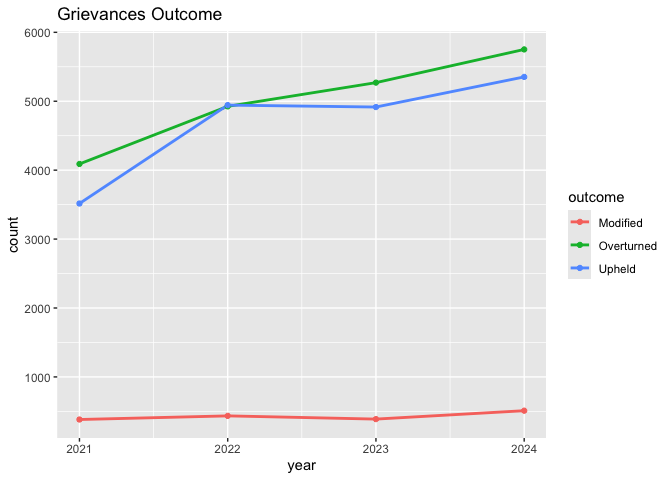

In [ ]:
 ggplot(gr_outcome,aes(x = year, y = count, color = outcome)) +
  geom_line(size = 1) +
  geom_point()+
  labs(
    title = "Grievances Outcome"
  )

Overturned outcomes are the most common and continue to grow, meaning
insurers are increasingly siding with consumers

# Hospital Length Of Stay

## Creating dataset that has total amounts for length of stay grievances

In [ ]:
mia_los<- totals_only |>
select(year,grievances_upheld_number_for_hospital_los,grievances_overturned_number_for_hospital_los,grievances_modified_number_for_hospital_los)|>  group_by(year) |>
  pivot_longer(-year, names_to = "outcome", values_to = "count") |>
  mutate(
    outcome = outcome |>
      str_remove("grievances_") |>
      str_remove("_number") |>
      str_replace_all("_", " ") |>
      str_to_title()
  ) 

## Creating line graph for grievances outcome for hospital length of stay

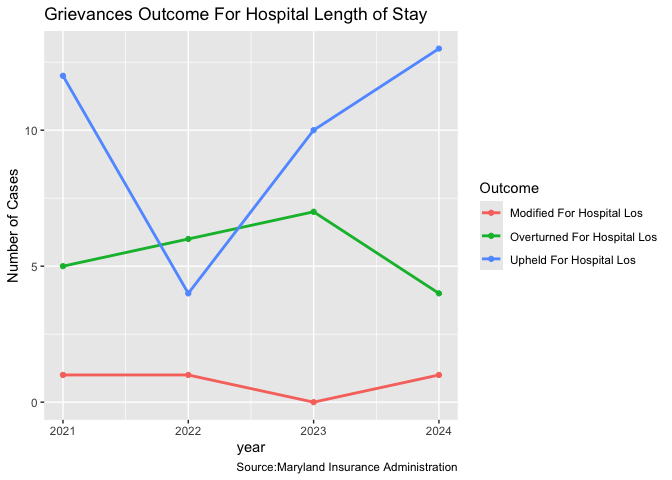

In [ ]:
ggplot(mia_los,aes(x = year, y = count, color = outcome)) +
  geom_line(size = 1) +
  geom_point() +
  labs(
    title = "Grievances Outcome For Hospital Length of Stay",
    y = "Number of Cases",
    color = "Outcome",
    caption = "Source:Maryland Insurance Administration"
  )

Upheld outcomes for hospital length-of-stay grievances surged in 2024
after a dip in 2022.

Overturned cases declined in 2024 after peaking in 2023 — consumers are
having less success challenging hospital stay denials in recent years.

# Emergency Cases Resolution Hours

## Creating dataset that has emergency cases resolution hours totals

In [ ]:
emer_res <- totals_only|>
  select(year, emergency_cases___resolution_hours_1_st_quarter_,emergency_cases___resolution_hours_2nd_quarter_,emergency_cases___resolution_hours_3rd__quarter_,emergency_cases___resolution_hours_4th_quarter_) 

## Pivoting dataset into long format for efficient graphing

In [ ]:
emer_res_long <- emer_res |>
  pivot_longer(
    cols = -year,
    names_to = "quarters",
    values_to = "resolution_hours"
  )|>
  mutate(
    quarters = quarters |>
      str_remove("emergency_cases___resolution_hours_") |>
      str_replace_all("_", " ") |>
      str_to_title()
  )

## Creating bar plot showing amount of hours it take to resolve an emergency grievance

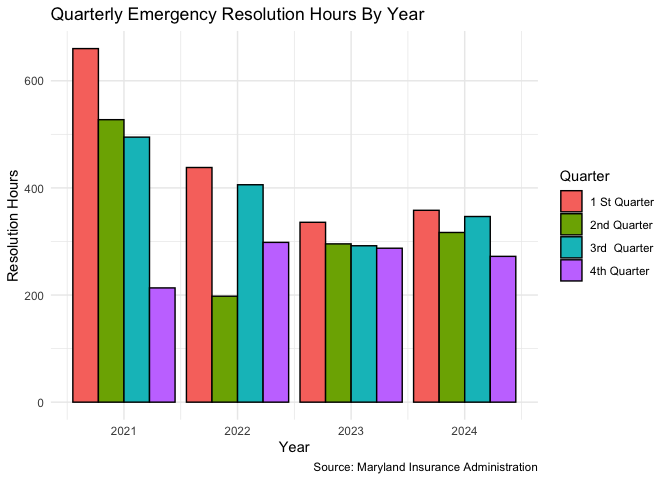

In [ ]:
ggplot(emer_res_long, aes(x = year, y = resolution_hours, fill = quarters)) +
  geom_bar(stat = "identity", color = "black",
           position = position_dodge(width = 0.9)) +
  labs(
    title = "Quarterly Emergency Resolution Hours By Year",
    x = "Year",
    y = "Resolution Hours",
    fill = "Quarter",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal()

Emergency resolution hours have dropped significantly since 2021, with
Q1 2024 averaging less than 400 hours compared to 660.1 in Q1 2021. Q1
consistently records the highest resolution hours each year , likely
reflecting post-holiday backlogs and early-year staffing constraints.

# Non-Emergency Cases Resolution Days

## Creating dataset that has non-emergency cases resolution hours totals

In [ ]:
non_emer_res <- totals_only|>
  select(year, non_emergency_cases___resolution_days_1st_quarter,non_emergency_cases___resolution_days_2nd_quarter,non_emergency_cases___resolution_days_3rd_quarter,non_emergency_cases___resolution_days_4th_quarter) 

In [ ]:
non_emer_res_long <- non_emer_res |>
  pivot_longer(
    cols = -year,
    names_to = "quarters",
    values_to = "resolution_days"
  )|>
  mutate(
    quarters = quarters |>
      str_remove("non_emergency_cases___resolution_days_") |>
      str_replace_all("_", " ") |>
      str_to_title()
  )

## Creating bar plot showing amount of days it take to resolve an non-emergency grievance

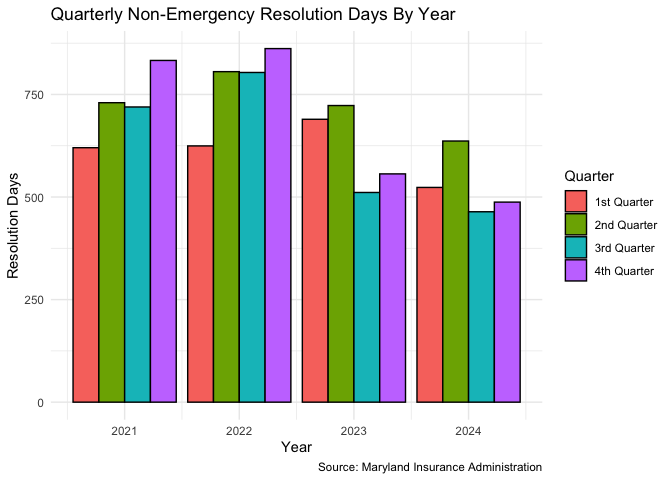

In [ ]:
ggplot(non_emer_res_long, aes(x = year, y = resolution_days, fill = quarters)) +
  geom_bar(stat = "identity", color = "black",
           position = position_dodge(width = 0.9)) +
  labs(
    title = "Quarterly Non-Emergency Resolution Days By Year",
    x = "Year",
    y = "Resolution Days",
    fill = "Quarter",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal()

Non-emergency resolution days peaked in Q4 2022 at 861.8 and have been
declining since, reflecting improved processing efficiency across all
quarters.

All 2024 quarters are well below 2022 peaks, suggesting improvements in
handling non-urgent cases.

# MIA Outcome

## Creating a chart that has numbers of mia outcomes for complaints

In [ ]:
mia_dec<- totals_only |>
  select(year,carrier_upheld_by_mia_number,carrier_modified_by_mia_number,carrier_reversed_by_mia_number)|>
  pivot_longer(-year, names_to = "outcome", values_to = "count") |>
  mutate(
    outcome = outcome |>
      str_remove("grievances_") |>
      str_remove("_number") |>
      str_replace_all("_", " ") |>
      str_to_title()
  ) 

## Plotting line graph showing MIA’s decision for complaints

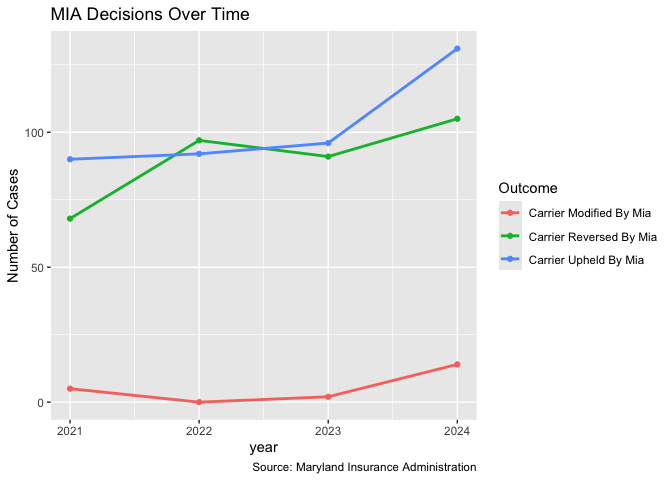

In [ ]:
  ggplot(mia_dec,aes(x = year, y = count, color = outcome)) +
  geom_line(size = 1) +
  geom_point() +
  labs(
    title = "MIA Decisions Over Time",
    y = "Number of Cases",
    color = "Outcome",
    caption = "Source: Maryland Insurance Administration"
  )

Carrier Upheld by MIA decisions rose sharply in 2024, indicating the MIA
is increasingly ruling in favor of insurers across all case types.

Carrier Reversed by MIA cases are also growing, showing the agency
remains active in holding insurers accountable in certain circumstances.

## Creating dataset that has data for MIA’s outcome for complaints by procedure

In [ ]:
admin_clean <- admin |>
  filter(type_of_procedure != "TOTAL") |>
  pivot_longer(
    cols = c(
      upheld_by_mia_number,
      reversed_by_mia_number,
      modifed_by_mia_number,
      carrier_reversed_itself_during_investigation_number
    ),
    names_to = "outcome",
    values_to = "count"
  ) |>
  mutate(
    outcome = outcome |>
      str_remove("_number") |>
      str_replace_all("_", " ") |>
      str_to_title()
  ) |>
  group_by(type_of_procedure) |>
  filter(sum(count, na.rm = TRUE) >= 10) |> 
  ungroup()

## Creating facet plots that shows MIA’s appeal decisions

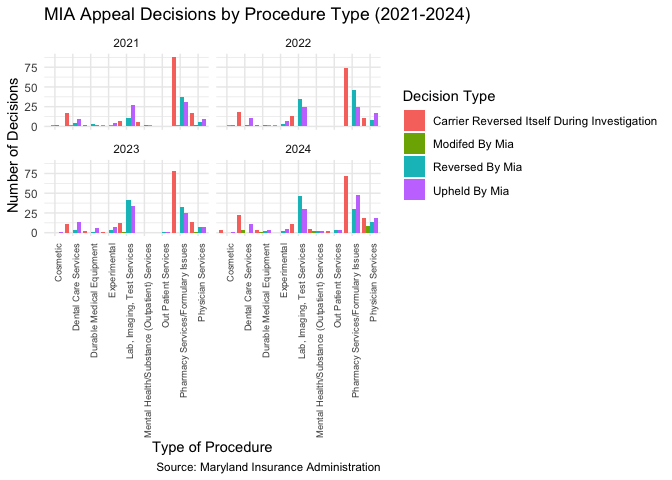

In [ ]:
ggplot(admin_clean,aes(x = type_of_procedure, y = count, fill = outcome)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  facet_wrap(~ year, ncol = 2) +
  labs(
    title = "MIA Appeal Decisions by Procedure Type (2021-2024)",
    x = "Type of Procedure",
    y = "Number of Decisions",
    fill = "Decision Type",
    caption = "Source: Maryland Insurance Administration"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 7))

Pharmacy/Formulary Issues and Lab/Imaging and Test generate the most MIA
appeal activity each year, making them the highest-friction service
categories.

High volumes of Carrier Reversed Itself During Investigation suggest
insurers frequently back down when they are being investigated